# Is NeuroVault a usable training corpus?

Two model ideas depend on the same question — what labelled images are
actually in here:

1. **A statistic-type and modality classifier.** Given a map, predict whether
   it is fMRI / VBM / DTI and whether it is a Z / T / P map. Every uploaded map
   already carries these as *required* fields, so they are free labels.
2. **An image-side CLIP-style decoder.** Existing decoders are trained on
   coordinates. Training on images needs image↔text pairs, which here means a
   map plus a task label and ideally free text.

Unlike the decoder-upload analysis, **mass uploads are welcome here** — for
training purposes a large well-annotated collection is an asset, not noise.
The filter that matters is *"does this image carry any usable annotation"*,
and above all a real task label.

**Neuroscout** (owner 5761) is still excluded: it is ~half the database, and
its naturalistic-stimulus maps are a single homogeneous source that would
dominate any training set and misrepresent generalisation.

In [1]:
import numpy as np
import pandas as pd

from nv_load import (BLANK, REST_EYES_CLOSED_ID, REST_EYES_OPEN_ID, answered,
                     barh, blank, cat, is_none_other, load, num, out_dir,
                     save, setup_plots, task_names)

plt = setup_plots()
OUT = out_dir("image_text_corpus")

sm, coll = load()
cog = sm["cognitive_paradigm_cogatlas_id"]

Loading february_2024  (exclude_neuroscout=True)


  excluded Neuroscout (owner 5761): 3889 collections, 289248 maps (51.7% of all maps)


  analysing 9507 collections / 269934 maps (dump totals: 13396 / 559182)


## 1. Classifier labels: how much free supervision is there?

These four fields were required at upload, so coverage should be high. That is
what makes the classifier cheap to build — no annotation round needed.

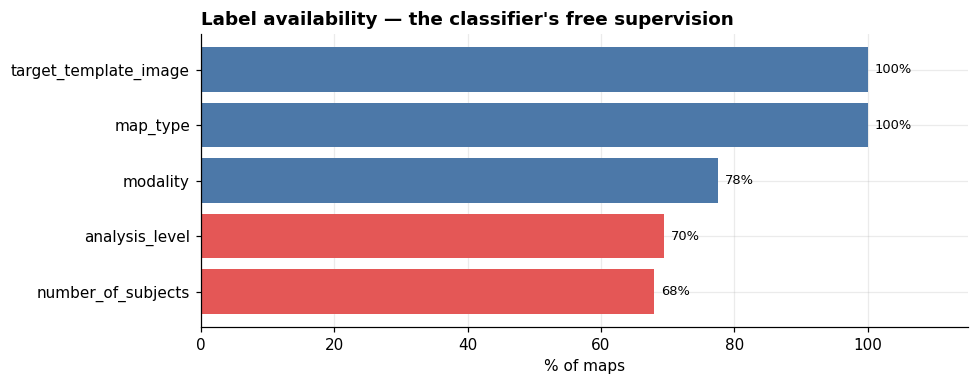

,n,pct
map_type,269933,100.0
modality,209432,77.6
target_template_image,269934,100.0
analysis_level,187692,69.5
number_of_subjects,183537,68.0


In [2]:
labels = {
    "map_type": sm["map_type"] != BLANK,
    "modality": sm["modality"] != BLANK,
    "target_template_image": ~blank(sm["target_template_image"]),
    "analysis_level": sm["analysis_level"] != BLANK,
    "number_of_subjects": sm["n_subj"].notna(),
}
lab = pd.Series({k: round(100 * v.mean(), 1) for k, v in labels.items()})

fig, ax = plt.subplots(figsize=(9, 3.6))
barh(ax, lab, "Label availability — the classifier's free supervision",
     xlabel="% of maps", fmt="{:.0f}%",
     highlight={"analysis_level", "number_of_subjects"}, highlight_color="#E45756")
plt.tight_layout()
plt.show()

save(OUT, "01_label_availability", pd.DataFrame({
    "n": {k: int(v.sum()) for k, v in labels.items()}, "pct": lab}))

The two in red were **optional** at upload, and they are the two that matter
most downstream: `analysis_level` decides whether a map is usable for
meta-analysis at all. That makes it the most valuable classifier target, not
the easiest one.

## 2. Class balance for the two classifier targets

Accuracy is meaningless without knowing the base rates. A classifier that
always predicts the majority class would already score well here.

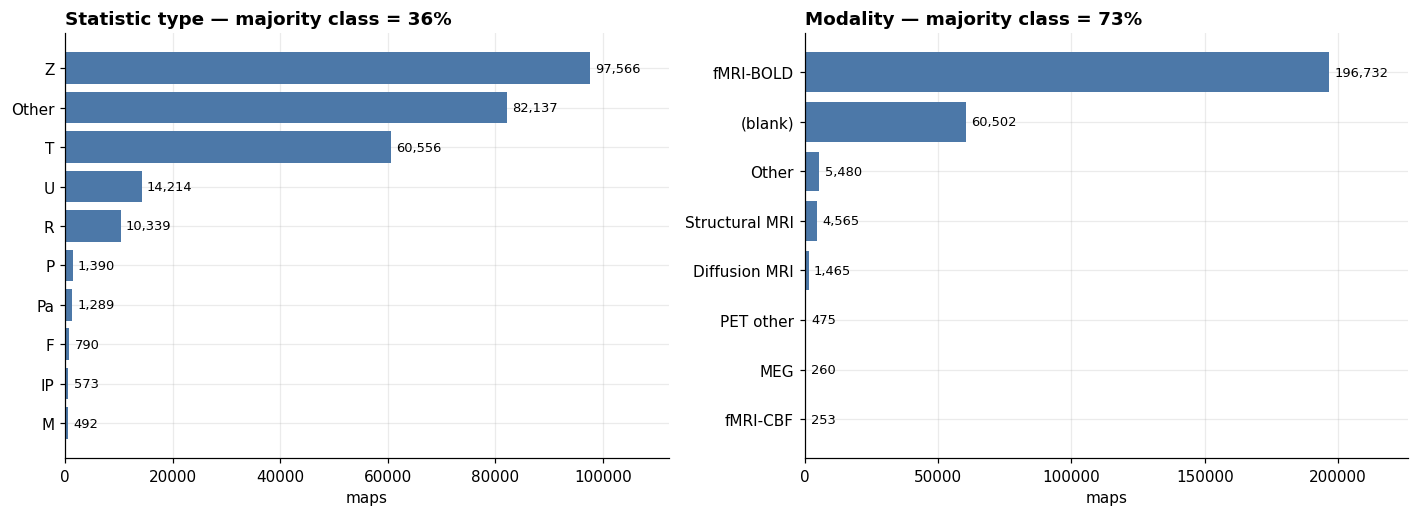

,n,pct
modality,,
fMRI-BOLD,196732,72.9
(blank),60502,22.4
Other,5480,2.0
Structural MRI,4565,1.7
Diffusion MRI,1465,0.5
PET other,475,0.2
MEG,260,0.1
fMRI-CBF,253,0.1
PET FDG,141,0.1


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
mt = sm["map_type"].value_counts()
md = sm["modality"].value_counts()
barh(axes[0], mt.head(10), f"Statistic type — majority class = {100*mt.iloc[0]/mt.sum():.0f}%")
barh(axes[1], md.head(8), f"Modality — majority class = {100*md.iloc[0]/md.sum():.0f}%")
plt.tight_layout()
plt.show()

save(OUT, "02_class_balance_map_type", pd.DataFrame({
    "n": mt, "pct": (100 * mt / mt.sum()).round(1)}))
save(OUT, "03_class_balance_modality", pd.DataFrame({
    "n": md, "pct": (100 * md / md.sum()).round(1)}))

In [4]:
# Minority classes are what a useful classifier has to get right, so count how
# many are viable to learn at all.
viable = pd.DataFrame({
    "map_type classes": [int((mt >= 100).sum()), int((mt >= 1000).sum()), len(mt)],
    "modality classes": [int((md >= 100).sum()), int((md >= 1000).sum()), len(md)],
}, index=["with >=100 examples", "with >=1000 examples", "total classes"])
save(OUT, "04_viable_classes", viable)

,map_type classes,modality classes
with >=100 examples,11,9
with >=1000 examples,7,5
total classes,14,11


## 3. The task-annotation funnel

For CLIP-style training the unit is an image paired with text. This is the
funnel from "every map" down to "map with a real task and free text".

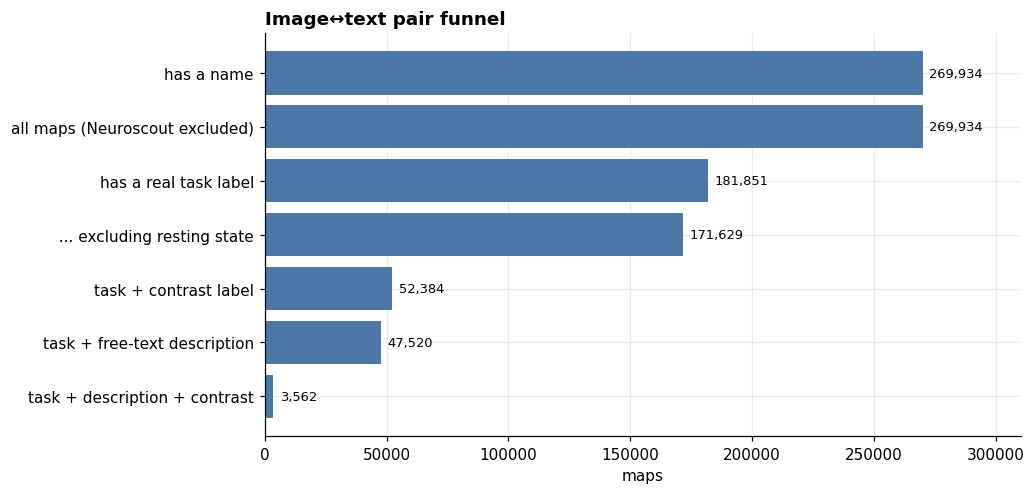

,maps
all maps (Neuroscout excluded),269934
has a name,269934
has a real task label,181851
... excluding resting state,171629
task + free-text description,47520
task + contrast label,52384
task + description + contrast,3562


In [5]:
has_task = answered(cog)
has_desc = ~blank(sm["description"])
has_name = ~blank(sm["name"])
has_contrast = answered(sm["cognitive_contrast_cogatlas_id"])
has_cdef = answered(sm["contrast_definition"])
is_rest = cog.isin([REST_EYES_OPEN_ID, REST_EYES_CLOSED_ID])

funnel = pd.Series({
    "all maps (Neuroscout excluded)": len(sm),
    "has a name": int(has_name.sum()),
    "has a real task label": int(has_task.sum()),
    "  ... excluding resting state": int((has_task & ~is_rest).sum()),
    "task + free-text description": int((has_task & has_desc).sum()),
    "task + contrast label": int((has_task & has_contrast).sum()),
    "task + description + contrast": int((has_task & has_desc & has_contrast).sum()),
})

fig, ax = plt.subplots(figsize=(9.5, 4.6))
barh(ax, funnel, "Image↔text pair funnel", xlabel="maps")
plt.tight_layout()
plt.show()

save(OUT, "05_text_funnel", funnel.to_frame("maps"))

The task field has three states, not two: a real task, the explicit
*"None / Other"* choice, and blank. Pandas' default NA handling merges the
last two, which is worth knowing — but note the scale here.

Across the **whole** dump, "None / Other" covers 301,879 maps and looks like a
major finding about user behaviour. Excluding Neuroscout it collapses to
**12,688**. That mass was one uploader whose naturalistic stimuli have no
Cognitive Atlas equivalent, not a population of users dodging the question.
Either way it is unusable as a training label, so it is excluded from every
count above.

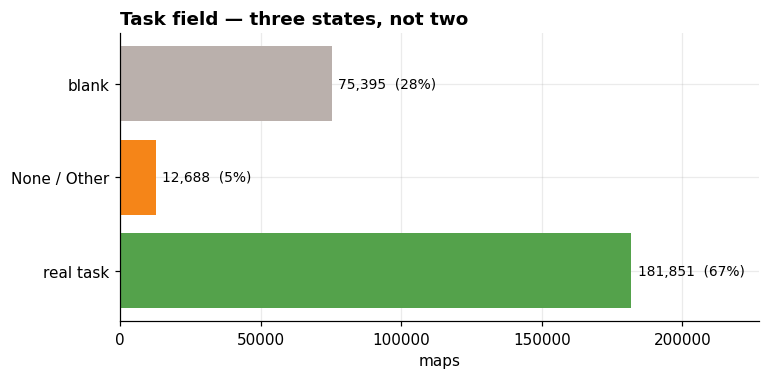

,maps
real task selected,181851
explicitly 'None / Other',12688
left blank,75395


In [6]:
three = pd.Series({
    "real task selected": int(has_task.sum()),
    "explicitly 'None / Other'": int(is_none_other(cog).sum()),
    "left blank": int(blank(cog).sum()),
})
fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.barh(["real task", "None / Other", "blank"], three.values,
        color=["#54A24B", "#F58518", "#BAB0AC"])
ax.set_title("Task field — three states, not two")
ax.set_xlabel("maps")
for y, v in enumerate(three.values):
    ax.text(v + len(sm) * 0.008, y, f"{v:,}  ({100*v/len(sm):.0f}%)",
            va="center", fontsize=9)
ax.set_xlim(0, three.max() * 1.25)
plt.show()

save(OUT, "06_task_three_states", three.to_frame("maps"))

## 4. Is the labelled set diverse, or one big collection?

A training set of 40k images drawn from three collections is not a training
set of 40k images. This is the concentration check.

In [7]:
usable = sm[has_task].copy()
per_task = usable["cognitive_paradigm_cogatlas_id"].value_counts()
per_coll = usable["collection_id"].value_counts()

conc = pd.Series({
    "usable maps (real task)": len(usable),
    "distinct tasks": int(per_task.size),
    "distinct collections": int(per_coll.size),
    "top-10 tasks share (%)": round(100 * per_task.head(10).sum() / len(usable), 1),
    "top-10 collections share (%)": round(100 * per_coll.head(10).sum() / len(usable), 1),
    "tasks with >=100 maps": int((per_task >= 100).sum()),
    "tasks with >=1000 maps": int((per_task >= 1000).sum()),
})
save(OUT, "07_concentration", conc.to_frame("value"))

,value
usable maps (real task),181851.0
distinct tasks,524.0
distinct collections,4041.0
top-10 tasks share (%),50.2
top-10 collections share (%),67.0
tasks with >=100 maps,117.0
tasks with >=1000 maps,30.0


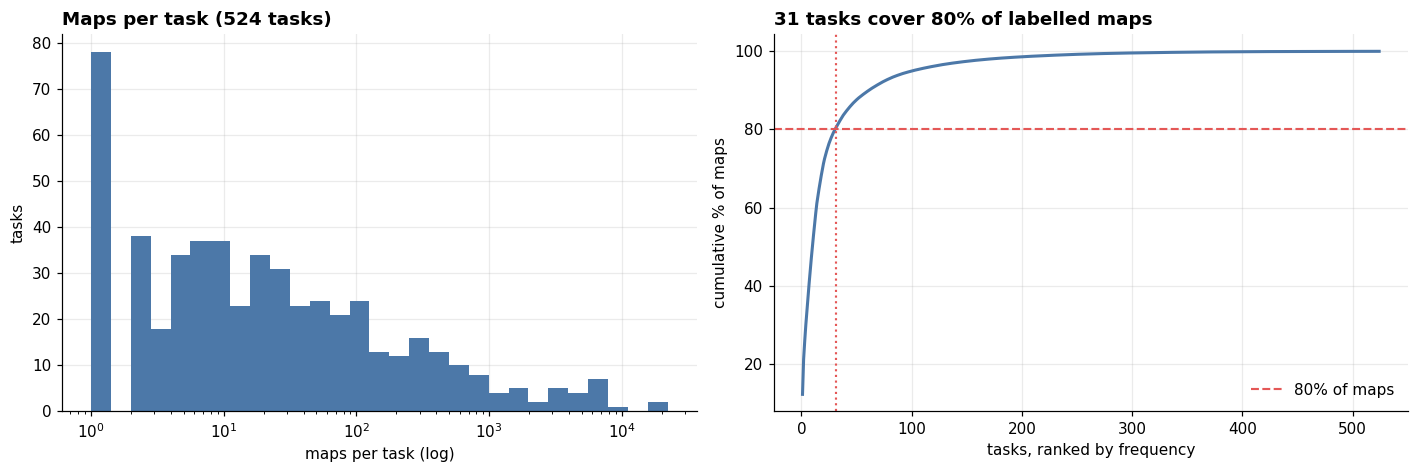

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
axes[0].hist(per_task.values, bins=np.logspace(0, np.log10(per_task.max()), 30),
             color="#4C78A8")
axes[0].set_xscale("log")
axes[0].set_title(f"Maps per task ({per_task.size} tasks)")
axes[0].set_xlabel("maps per task (log)")
axes[0].set_ylabel("tasks")

cum = 100 * per_task.sort_values(ascending=False).cumsum() / len(usable)
axes[1].plot(range(1, len(cum) + 1), cum.values, color="#4C78A8", lw=2)
axes[1].axhline(80, color="#E45756", ls="--", lw=1.4, label="80% of maps")
n80 = int((cum.values < 80).sum()) + 1
axes[1].axvline(n80, color="#E45756", ls=":", lw=1.4)
axes[1].set_title(f"{n80} tasks cover 80% of labelled maps")
axes[1].set_xlabel("tasks, ranked by frequency")
axes[1].set_ylabel("cumulative % of maps")
axes[1].legend(frameon=False)
plt.tight_layout()
plt.show()

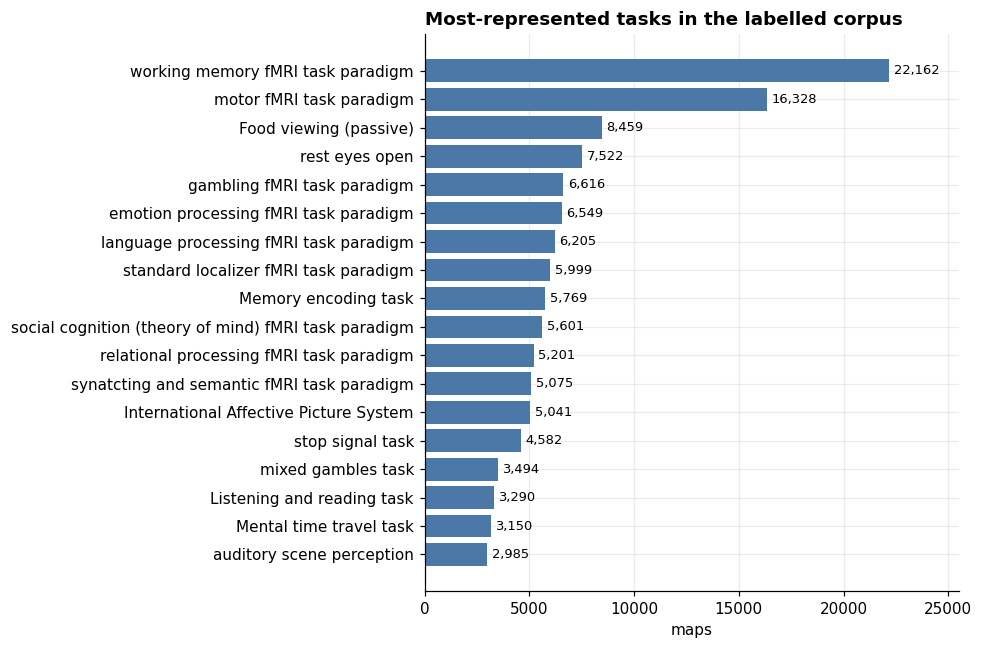

,maps
cognitive_paradigm_cogatlas_id,
working memory fMRI task paradigm,22162
motor fMRI task paradigm,16328
Food viewing (passive),8459
rest eyes open,7522
gambling fMRI task paradigm,6616
emotion processing fMRI task paradigm,6549
language processing fMRI task paradigm,6205
standard localizer fMRI task paradigm,5999
Memory encoding task,5769


In [9]:
fig, ax = plt.subplots(figsize=(9, 6))
names = task_names().set_index("cog_atlas_id")["name"]
topn = per_task.head(18).rename(index=names)
barh(ax, topn, "Most-represented tasks in the labelled corpus")
plt.tight_layout()
plt.show()

save(OUT, "08_top_tasks", per_task.head(40).rename(index=names).to_frame("maps"))

## 5. How good is the text?

CLIP-style training needs text with signal in it. Names are often filenames;
descriptions are the richer source.

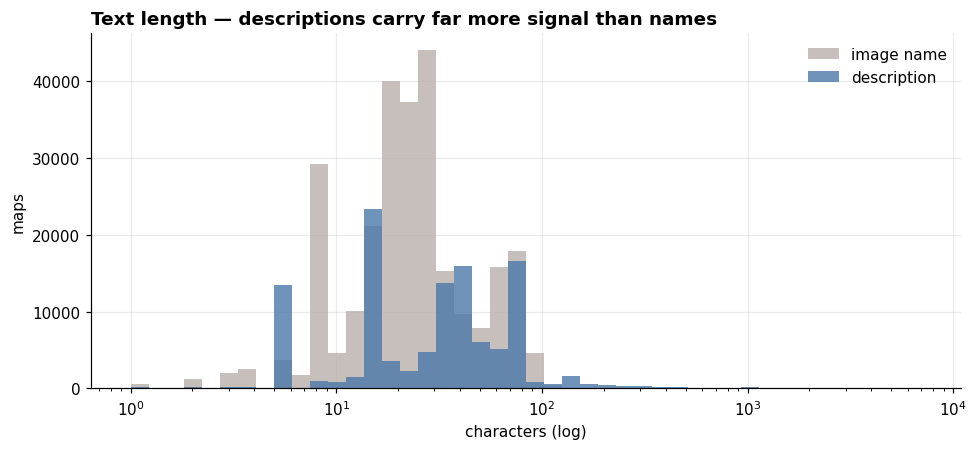

,image name,description,contrast_definition
count,269934.0,114419.0,93564.0
mean,28.7,45.9,27.0
std,20.9,94.9,20.2
min,1.0,1.0,1.0
25%,16.0,15.0,9.0
50%,23.0,32.0,24.0
75%,32.0,55.0,40.0
95%,75.0,83.0,62.0
max,200.0,6977.0,200.0


In [10]:
desc_len = sm.loc[has_desc, "description"].str.len()
name_len = sm.loc[has_name, "name"].str.len()

fig, ax = plt.subplots(figsize=(9, 4.2))
bins = np.logspace(0, np.log10(max(desc_len.max(), 10)), 45)
ax.hist(name_len, bins=bins, color="#BAB0AC", label="image name", alpha=0.8)
ax.hist(desc_len, bins=bins, color="#4C78A8", label="description", alpha=0.8)
ax.set_xscale("log")
ax.set_title("Text length — descriptions carry far more signal than names")
ax.set_xlabel("characters (log)")
ax.set_ylabel("maps")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

save(OUT, "09_text_length", pd.DataFrame({
    "image name": name_len.describe(percentiles=[.25, .5, .75, .95]),
    "description": desc_len.describe(percentiles=[.25, .5, .75, .95]),
    "contrast_definition": sm.loc[has_cdef, "contrast_definition"].str.len()
                             .describe(percentiles=[.25, .5, .75, .95]),
}).round(1))

`contrast_definition` is worth noting separately: it is free text written to
describe *what the map shows*, which is closer to a caption than anything else
in the schema.

In [11]:
save(OUT, "10_caption_candidates", pd.Series({
    "has contrast_definition": int(has_cdef.sum()),
    "  and a real task": int((has_cdef & has_task).sum()),
    "  and a description": int((has_cdef & has_desc).sum()),
    "median length (chars)": int(sm.loc[has_cdef, "contrast_definition"].str.len().median()),
}, name="value").to_frame())

,value
has contrast_definition,93564
and a real task,81421
and a description,5973
median length (chars),24


## 6. Candidate training sets

Three tiers, from most permissive to most curated.

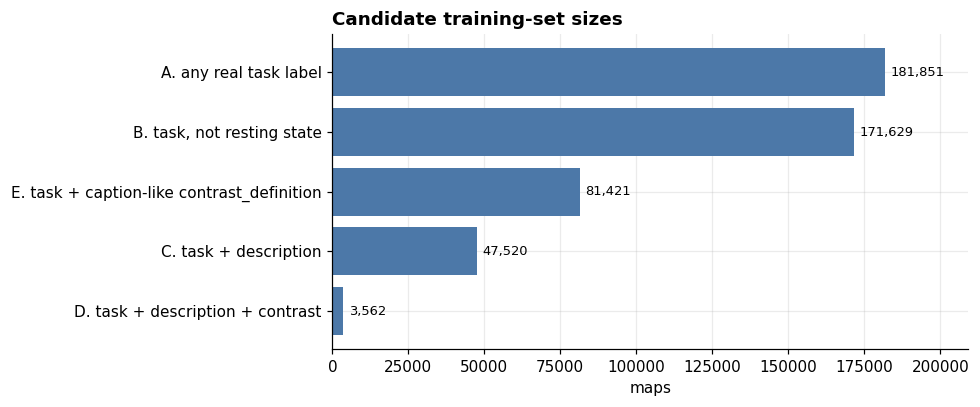

,maps,distinct tasks,distinct collections,median maps/task
A. any real task label,181851,524,4041,15
"B. task, not resting state",171629,522,3282,14
C. task + description,47520,325,1454,9
D. task + description + contrast,3562,198,679,5
E. task + caption-like contrast_definition,81421,255,550,13


In [12]:
tiers = {
    "A. any real task label": has_task,
    "B. task, not resting state": has_task & ~is_rest,
    "C. task + description": has_task & has_desc,
    "D. task + description + contrast": has_task & has_desc & has_contrast,
    "E. task + caption-like contrast_definition": has_task & has_cdef,
}
rows = []
for name, mask in tiers.items():
    sub = sm[mask]
    rows.append({
        "maps": int(mask.sum()),
        "distinct tasks": sub["cognitive_paradigm_cogatlas_id"].nunique(),
        "distinct collections": sub["collection_id"].nunique(),
        "median maps/task": int(sub["cognitive_paradigm_cogatlas_id"]
                               .value_counts().median()) if mask.sum() else 0,
    })
tier_tbl = pd.DataFrame(rows, index=list(tiers))

fig, ax = plt.subplots(figsize=(9, 3.8))
barh(ax, tier_tbl["maps"], "Candidate training-set sizes", xlabel="maps")
plt.tight_layout()
plt.show()

save(OUT, "11_training_tiers", tier_tbl)

## Takeaways

* **The classifier has free labels.** `map_type` and `modality` are near-fully
  populated because the upload form required them. The catch is class
  imbalance, not label scarcity — report per-class recall, not accuracy.
* **`analysis_level` is the valuable target.** It was optional at upload, is
  missing on a large minority of maps, and is the field that gates
  meta-analysis reuse. Predicting it is worth more than predicting statistic
  type, which is largely rule-derivable anyway.
* **The CLIP corpus is real but concentrated.** Check the cumulative-coverage
  plot: a small number of tasks carry most of the labelled maps, so any
  train/test split must be by *collection*, never by image, or the reported
  performance will be leakage.
* **`contrast_definition` is the best caption source** in the schema and was
  not part of the original plan.

In [13]:
print(f"Wrote {len(list(OUT.glob('*.csv')))} tables to {OUT}/")

Wrote 11 tables to audit_output/february_2024/image_text_corpus/
